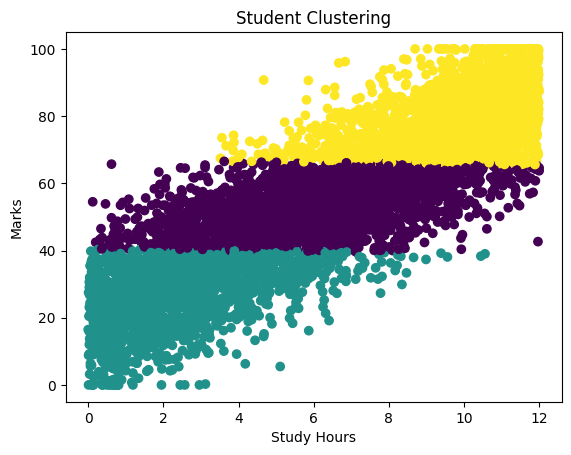

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('student_performance.csv')

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df)

plt.scatter(df['study_hours'], df['marks'], c=df['cluster'])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Student Clustering")
plt.show()

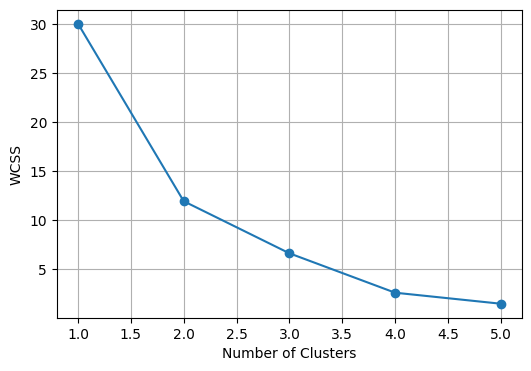

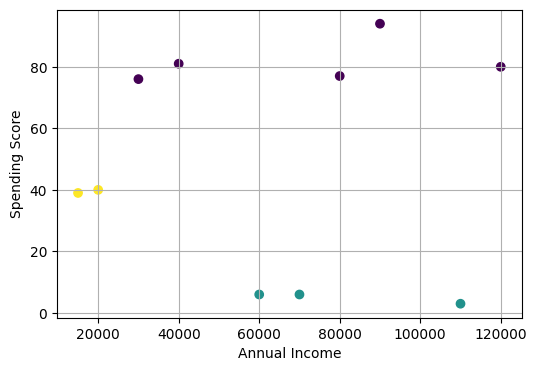

         user_id  annual_income  spending_score  visit_frequency
cluster                                                         
0            5.6        72000.0            81.6             20.0
1            7.0        80000.0             5.0              2.0
2            3.0        17500.0            39.5              6.0
   user_id  annual_income  spending_score  visit_frequency  cluster  \
0        1          15000              39                5        2   
1        2          40000              81               20        0   
2        3          60000               6                2        1   
3        4          80000              77               18        0   
4        5          20000              40                7        2   
5        6         120000              80               25        0   
6        7          30000              76               15        0   
7        8          70000               6                3        1   
8        9          90000           

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    "user_id": [1,2,3,4,5,6,7,8,9,10],
    "annual_income": [15000, 40000, 60000, 80000, 20000, 120000, 30000, 70000, 90000, 110000],
    "spending_score": [39, 81, 6, 77, 40, 80, 76, 6, 94, 3],
    "visit_frequency": [5, 20, 2, 18, 7, 25, 15, 3, 22, 1]
}

df = pd.DataFrame(data)

X = df[['annual_income', 'spending_score', 'visit_frequency']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,6), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(df['annual_income'], df['spending_score'], c=df['cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid()
plt.show()

cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

def label_segment(row):
    if row['cluster'] == 0:
        return "Budget Customers"
    elif row['cluster'] == 1:
        return "Premium Customers"
    else:
        return "Regular Customers"

df['segment'] = df.apply(label_segment, axis=1)

print(df)